# Restricciones monotónicas

Ejemplo 

# Libs & Config

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import kagglehub
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from great_tables import GT, from_column, style, loc
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import sklearn

from catboost import CatBoostClassifier
from sklearn.inspection import PartialDependenceDisplay

In [2]:
PATH_DATA = "../../data/df_german_credit.csv"
TARGET = 'Risk'
COLOR_GREEN = "#255255"
COLOR_LIGHTGREEN = "#BDCBCC"

sklearn.set_config(transform_output="pandas")

# Datos

In [ ]:
path_data = "../../data/GiveMeSomeCredit"

df_train = pd.read_csv(f"{path_data}/cs-training.csv").drop("Unnamed: 0", axis=1)
df_test = pd.read_csv(f"{path_data}/cs-test.csv").drop("Unnamed: 0", axis=1)

df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

print(f"N train: {df_train.shape[0]} ({df_train.shape[1]} columns)")
print(f"N test: {df_test.shape[0]} ({df_test.shape[1]} columns)")

N train: 150000 (11 columns)
N test: 101503 (11 columns)


In [44]:
TARGET_COL = "SeriousDlqin2yrs"
selected_columns = ['DebtRatio','Age']
X_train = df_train.drop(TARGET_COL, axis=1).assign(DebtRatio=lambda x: x['DebtRatio'].clip(0,1))
X_test = df_test.drop(TARGET_COL, axis=1).assign(DebtRatio=lambda x: x['DebtRatio'].clip(0,1))
y_train = df_train[TARGET_COL]
y_test = df_test[TARGET_COL]

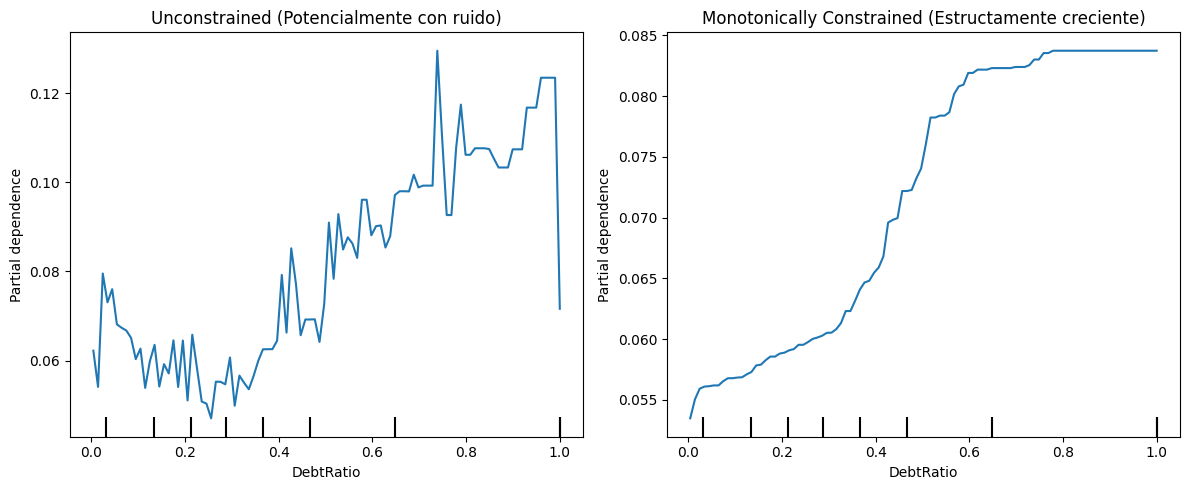

In [47]:
# 3. Fit Unconstrained Model
model_unconstrained = CatBoostClassifier(iterations=100, depth=8, verbose=0, random_seed=42)
model_unconstrained.fit(X_train[['DebtRatio','age']], y_train)

# 4. Fit Monotonically Constrained Model
# 1 = Increasing risk, -1 = Decreasing risk
constraints = {
    # 'age': -1,
    # 'RevolvingUtilizationOfUnsecuredLines': 1,
    # 'NumberOfTimes90DaysLate': 1,
    'DebtRatio': 1
}

model_constrained = CatBoostClassifier(
    iterations=100, 
    depth=8, 
    monotone_constraints=constraints, 
    verbose=0, 
    random_seed=42
)
model_constrained.fit(X_train[['DebtRatio','age']], y_train)

# 5. Compare Partial Dependence Plots for 'NumberOfTimes90DaysLate'
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

PartialDependenceDisplay.from_estimator(
    model_unconstrained, X_train[['DebtRatio','age']], features=['DebtRatio'], ax=axes[0]
)
axes[0].set_title("Unconstrained (Potencialmente con ruido)")

PartialDependenceDisplay.from_estimator(
    model_constrained, X_train[['DebtRatio','age']], features=['DebtRatio'], ax=axes[1]
)
axes[1].set_title("Monotonically Constrained (Estructamente creciente)")

plt.tight_layout()
plt.show()

In [51]:
X_example = pd.DataFrame({
    'age': [30],
    'DebtRatio': [0.75]
}, index=['example'])

pred_unconstrained = model_unconstrained.predict_proba(X_example)[:,1][0]
pred_constrained = model_constrained.predict_proba(X_example)[:,1][0]

display(Markdown(f"""
    Probabilidad predicha por el modelo no restricto: {pred_unconstrained:.3f}
    Probabilidad predicha por el modelo restricto: {pred_constrained:.3f}
"""))

X_example['DebtRatio'] = [0.85]

pred_unconstrained = model_unconstrained.predict_proba(X_example)[:,1][0]
pred_constrained = model_constrained.predict_proba(X_example)[:,1][0]

Markdown(f"""
    Probabilidad predicha por el modelo no restricto: {pred_unconstrained:.3f}
    Probabilidad predicha por el modelo restricto: {pred_constrained:.3f}
""")


    Probabilidad predicha por el modelo no restricto: 0.127
    Probabilidad predicha por el modelo restricto: 0.118



    Probabilidad predicha por el modelo no restricto: 0.109
    Probabilidad predicha por el modelo restricto: 0.118


In [ ]:
2% de cambio en probabilidad, incrementó su endeudamiento en x% y esto redujo su probabilidad de mora en 2%, cuando la dería haber incrementado o mantener constante. 

0.018000000000000002

In [7]:
sample_individual = X_test.sample(1, random_state=42)
sample_individual['DebtRatio'] = [0.01]
pred_unconstrained = model_unconstrained.predict_proba(sample_individual)[:,1][0]
pred_constrained = model_constrained.predict_proba(sample_individual)[:,1][0]

Markdown(f"""
    Probabilidad predicha por el modelo no restricto: {pred_unconstrained:.3f}
    Probabilidad predicha por el modelo restricto: {pred_constrained:.3f}
""")


    Probabilidad predicha por el modelo no restricto: 0.009
    Probabilidad predicha por el modelo restricto: 0.007


In [8]:
sample_individual = X_test.sample(1, random_state=42)
sample_individual['DebtRatio'] = [0.99]
pred_unconstrained = model_unconstrained.predict_proba(sample_individual)[:,1][0]
pred_constrained = model_constrained.predict_proba(sample_individual)[:,1][0]

Markdown(f"""
    Probabilidad predicha por el modelo no restricto: {pred_unconstrained:.3f}
    Probabilidad predicha por el modelo restricto: {pred_constrained:.3f}
""")


    Probabilidad predicha por el modelo no restricto: 0.013
    Probabilidad predicha por el modelo restricto: 0.015


# EDA

In [9]:
df_train[TARGET_COL].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [10]:
def map_color(data):
    return (data[TARGET_COL] == 1).map({True: COLOR_LIGHTGREEN, False: "white"})

(
    GT(df_train.sample(6, random_state=12).set_index(TARGET_COL).reset_index().round(2))
    .tab_style(
        style=style.fill(color=map_color),
        locations=loc.body(columns=df.columns.tolist()),
    )
    .tab_style(
        style=style.text(color="red", weight="bold"),
        locations=loc.body(TARGET_COL),
    )
    .tab_options(
        column_labels_background_color=COLOR_GREEN, table_font_names="Times New Roman"
    )
)

SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,0.85,67,3,1.15,2513.0,7,3,1,0,1.0
1,0.6,53,0,2620.0,,13,0,1,0,0.0
0,0.31,43,0,0.19,29000.0,15,0,3,0,4.0
0,0.03,66,0,0.64,5200.0,9,0,0,0,0.0
0,0.0,38,0,0.32,3261.0,3,0,1,0,0.0
0,0.02,45,0,2139.0,,3,0,1,0,0.0


In [11]:
?sns.displot

Signature:
sns.displot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    row=None,
    col=None,
    weights=None,
    kind='hist',
    rug=False,
    rug_kws=None,
    log_scale=None,
    legend=True,
    palette=None,
    hue_order=None,
    hue_norm=None,
    color=None,
    col_wrap=None,
    row_order=None,
    col_order=None,
    height=5,
    aspect=1,
    facet_kws=None,
    **kwargs,
)
Docstring:
Figure-level interface for drawing distribution plots onto a FacetGrid.

This function provides access to several approaches for visualizing the
univariate or bivariate distribution of data, including subsets of data
defined by semantic mapping and faceting across multiple subplots. The
``kind`` parameter selects the approach to use:

- :func:`histplot` (with ``kind="hist"``; the default)
- :func:`kdeplot` (with ``kind="kde"``)
- :func:`ecdfplot` (with ``kind="ecdf"``; univariate-only)

Additionally, a :func:`rugplot` can be added to any kind of plot to show
individual 

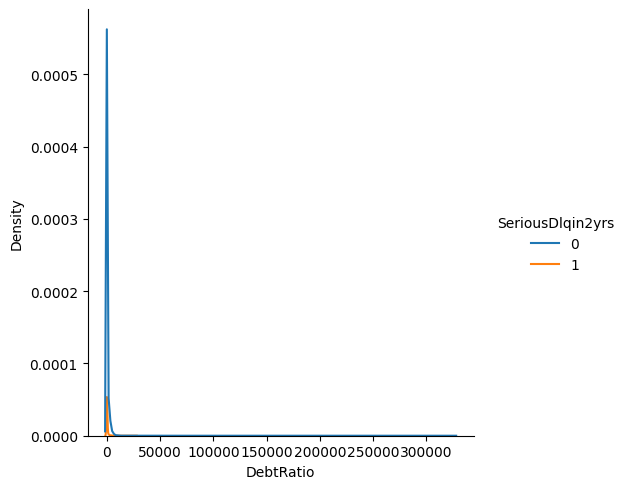

In [17]:
sns.displot(x='DebtRatio', hue=TARGET_COL, data=df_train.sample(10000), kind='kde')


# Modelo simple

In [50]:
y = df["target"]
X = df.drop(["target"], axis=1)[["age", "credit_amount", "checking_account"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42
)

y_train = y_train.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

display(Markdown(f"N observaciones en entrenamiento: {X_train.shape[0]}"))
display(Markdown(f"N observaciones en evaluación: {X_test.shape[0]}"))

N observaciones en entrenamiento: 500

N observaciones en evaluación: 500

In [59]:
numeric_transformer = Pipeline(
    [("impute", SimpleImputer(strategy="median"))]
)

categorical_transformer = Pipeline(
    [
        (
            "ohe",
            OneHotEncoder(
                min_frequency=0.05,
                drop="if_binary",
                handle_unknown="infrequent_if_exist",
                sparse_output=False,
            ),
        )
    ]
)

preproc = ColumnTransformer(
    [
        (
            "num",
            numeric_transformer,
            make_column_selector(dtype_include=["float", "int"]),
        ),
        (
            "cat",
            categorical_transformer,
            make_column_selector(dtype_include=["object", "category"]),
        ),
    ],
    verbose_feature_names_out=False,
)

In [64]:
df_train = pd.concat([preproc.fit_transform(X_train), y_train], axis=1)
display(GT(df_train.sample(2).round(2))
    .tab_options(
        column_labels_background_color=COLOR_GREEN,
        table_font_names="Times New Roman"
    )
)

age,credit_amount,checking_account_little,checking_account_moderate,checking_account_rich,checking_account_nan,target
42.0,1346.0,0.0,0.0,0.0,1.0,0
46.0,2476.0,0.0,0.0,0.0,1.0,0


In [69]:
(df_train.corr()
    .style.format(precision=2)
    .background_gradient(cmap="coolwarm")
)

,age,credit_amount,checking_account_little,checking_account_moderate,checking_account_rich,checking_account_nan,target
age,1.00,-0.01,0.01,-0.03,-0.00,0.01,-0.07
credit_amount,-0.01,1.00,-0.02,0.09,-0.09,-0.01,0.04
checking_account_little,0.01,-0.02,1.00,-0.36,-0.17,-0.51,0.26
checking_account_moderate,-0.03,0.09,-0.36,1.00,-0.16,-0.47,0.10
checking_account_rich,-0.00,-0.09,-0.17,-0.16,1.00,-0.22,-0.00
checking_account_nan,0.01,-0.01,-0.51,-0.47,-0.22,1.00,-0.32
target,-0.07,0.04,0.26,0.10,-0.00,-0.32,1.00


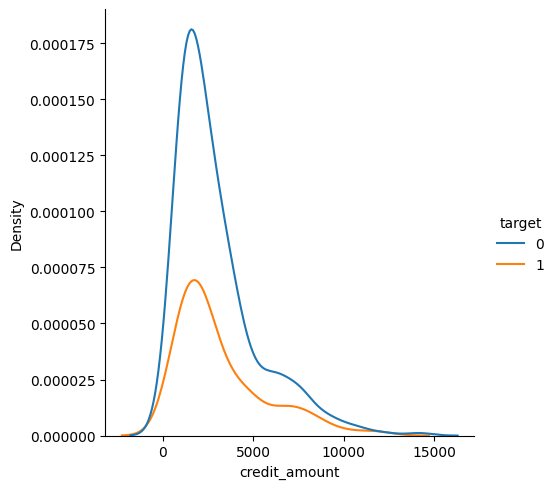

In [74]:
sns.displot(x="credit_amount", hue='target', data=df_train, kind="kde")

# Modelo con restricción monotónica